Using cache found in C:\Users\chris/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-12-20 Python-3.12.10 torch-2.9.1+cpu CPU

Fusing layers... 
Model summary: 261 layers, 61497430 parameters, 0 gradients, 154.5 GFLOPs
Adding AutoShape... 
C:\Users\chris/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


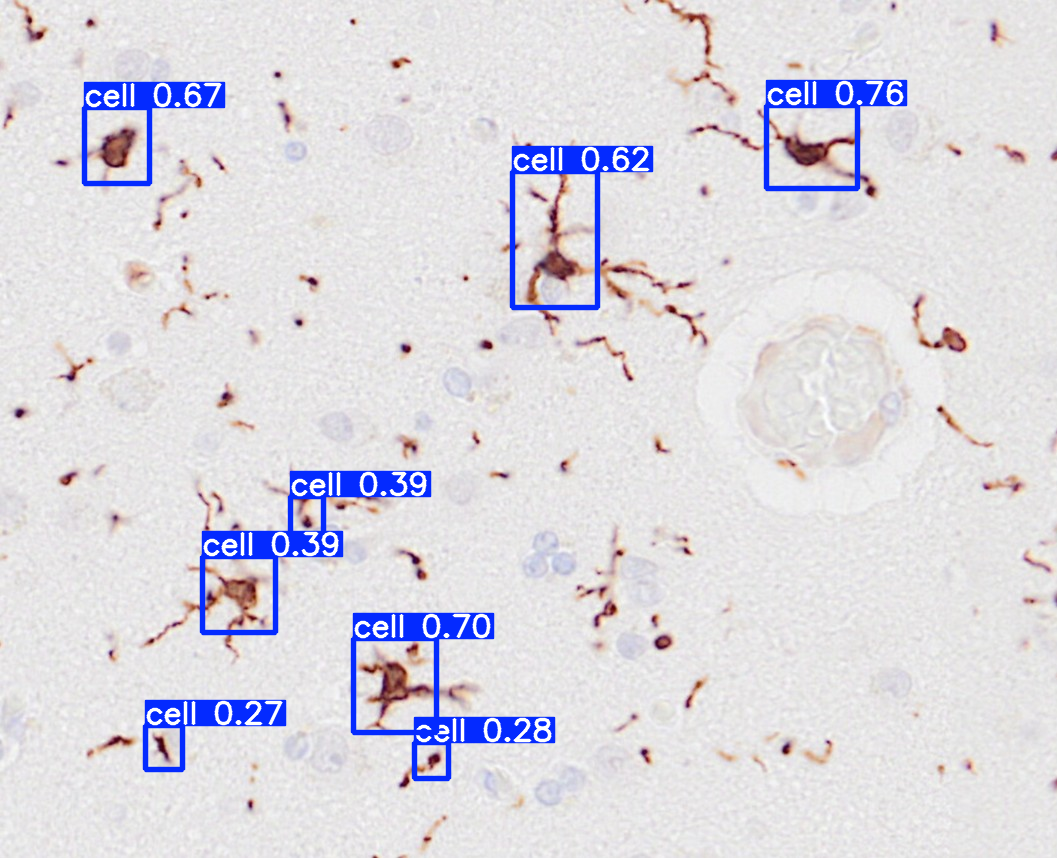

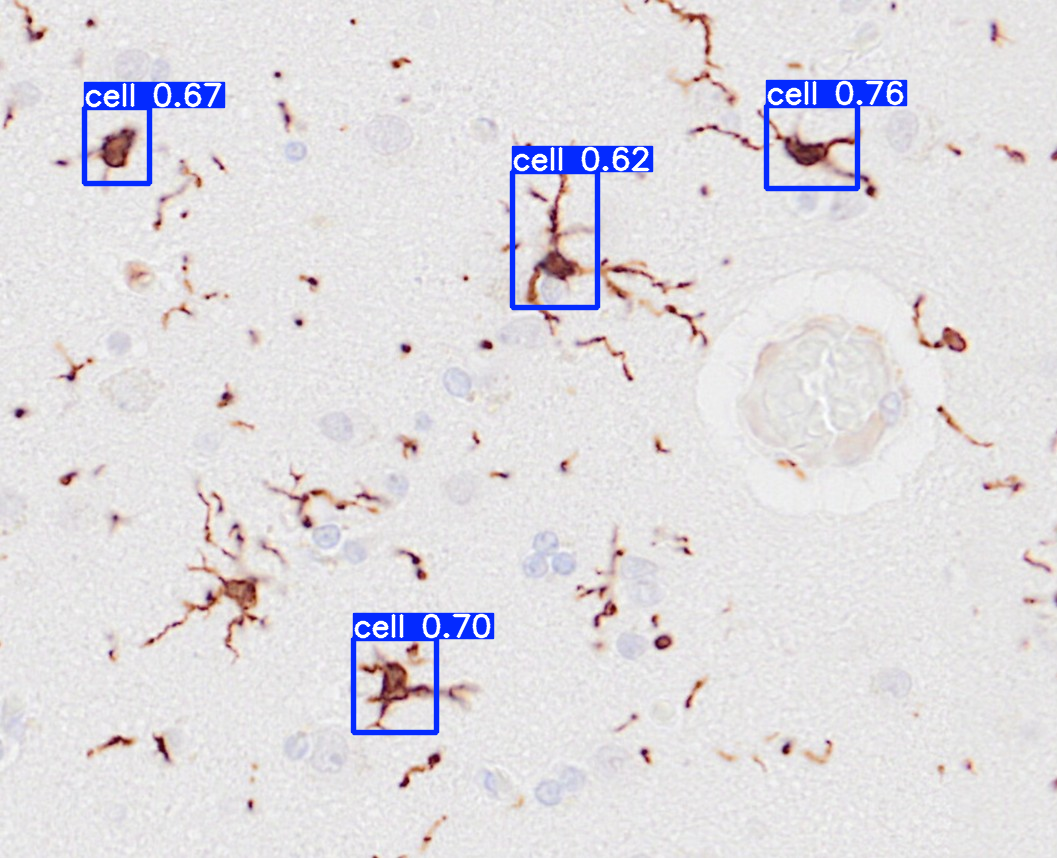

In [1]:
import torch
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamPredictor

# ----------------------
# 1. Load YOLOv5 model
# ----------------------
yolo = torch.hub.load(
    'ultralytics/yolov5',
    'custom',
    path='yolov3_weights.pt'
)


# image_path = "toy_dataset/microglia_big_screenshot.jpg"
image_path = "toy_dataset/third_screenshot.jpg"
# image_path = "toy_dataset/two_cells.jpg"

# Load image for SAM


results = yolo(image_path)
results.show()

# YOLOv5 format: [x1, y1, x2, y2, conf, class]
detections = results.xyxy[0]

# Keep only confidence > 0.5
filtered = detections[detections[:, 4] > 0.5]

# Replace detections inside results object
results.xyxy[0] = filtered

results.show()


# annotated_img = results.render()[0]  # numpy array (BGR)

# # Save to file
# cv2.imwrite(
#     "yolo_outputs/microglia_big_screenshot_yolo.png",
#     annotated_img
# )
# Get bounding boxes (xyxy)
boxes = results.xyxy[0][:, :4].cpu().numpy()  # shape (N, 4)

In [2]:
image = cv2.imread(image_path)
h, w = image.shape[:2]
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Extract red channel
red = image_rgb[:, :, 0]

# Hard threshold
threshold_value = 215  # tune this

_, binary = cv2.threshold(
    red,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)


cv2.imwrite("red_channel_threshold.png", binary)

image_rgb_binary = np.stack([binary, binary, binary], axis=-1)



In [3]:

# binary is now black & white
sam = sam_model_registry["vit_b"](
    checkpoint="sam_files/sam_vit_b_01ec64.pth"
)
sam.to("cuda" if torch.cuda.is_available() else "cpu")

predictor = SamPredictor(sam)
predictor.set_image(image_rgb)
# predictor.set_image(image_rgb_binary)


masks = []

prompt_type = "point"

for box in boxes:
    x1, y1, x2, y2 = box.astype(int)

    if prompt_type == "point":
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2


        mask, _, _ = predictor.predict(
            point_coords=np.array([[cx, cy]]),
            point_labels=np.array([1]),  # foreground
            multimask_output=False
        )

    else:
        # by default use the entire box as the prompt
        mask, _, _ = predictor.predict(
            box=np.array([x1, y1, x2, y2]),
            multimask_output=False
        )

    masks.append(mask[0])  # (H, W)

In [4]:
soma_masks = []
red = image_rgb[:, :, 0]

for box in boxes:
    x1, y1, x2, y2 = box.astype(int)

    # 1. Extract ROI from RED channel
    roi = red[y1:y2, x1:x2].astype(np.float32)

    # 2. Normalize
    roi = cv2.normalize(roi, None, 0, 255, cv2.NORM_MINMAX)

    # 3. INVERT so soma (dark) becomes bright
    roi_inv = 255 - roi

    # 4. Gaussian blur (soma-scale)
    blurred = cv2.GaussianBlur(
        roi_inv,
        (0, 0),
        sigmaX=6,   # tune: soma radius / ~2
        sigmaY=6
    )

    # 5. Relative threshold (NOT global)
    thresh = 0.7 * blurred.max()
    soma_roi = (blurred > thresh).astype(np.uint8) * 255

    # 6. Keep component containing the brightest pixel
    _, _, _, maxLoc = cv2.minMaxLoc(blurred)

    num_labels, labels = cv2.connectedComponents(soma_roi)
    soma_label = labels[maxLoc[1], maxLoc[0]]
    soma_roi = (labels == soma_label).astype(np.uint8) * 255

    # 7. Place back into full image
    soma_mask = np.zeros_like(binary)
    soma_mask[y1:y2, x1:x2] = soma_roi

    soma_masks.append(soma_mask)


In [5]:
import cv2
import numpy as np
import os

os.makedirs("soma_outputs/overlays", exist_ok=True)

# Copy original image (RGB)
overlay = image_rgb.copy()

for soma_mask in soma_masks:
    # soma_mask is uint8 {0,255} or bool, ensure uint8
    mask_uint8 = (soma_mask > 0).astype(np.uint8) * 255

    # Find contours of soma
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw soma contours (blue, slightly thicker)
    cv2.drawContours(
        overlay,
        contours,
        contourIdx=-1,
        color=(0, 0, 255),  # blue soma
        thickness=2
    )

# Save result
out_path = "soma_outputs/overlays/soma_outline_overlay.png"
cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


True

In [6]:
import cv2
import numpy as np

def fill_holes(binary_mask):
    """
    binary_mask: uint8 image with values {0,255}
    returns: uint8 image with holes filled
    """
    # Copy mask
    filled = binary_mask.copy()

    h, w = filled.shape

    # Flood fill from the outside
    mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(filled, mask, seedPoint=(0, 0), newVal=255)

    # Invert flood-filled image
    filled_inv = cv2.bitwise_not(filled)

    # Combine with original to fill holes
    return cv2.bitwise_or(binary_mask, filled_inv)


In [7]:
import os
import cv2
import numpy as np

os.makedirs("soma_outputs/masks", exist_ok=True)

filled_soma_masks = []

for i, soma_mask in enumerate(soma_masks):
    soma_uint8 = (soma_mask > 0).astype(np.uint8) * 255
    out_path = f"soma_outputs/masks/soma_{i:03d}.png"
    cv2.imwrite(out_path, soma_uint8)
    soma_filled = fill_holes(soma_uint8)
    filled_soma_masks.append(soma_filled)


print(len(filled_soma_masks))
for i, filled_soma_mask in enumerate(filled_soma_masks):
    out_path = f"soma_outputs/masks/soma_filled_{i:03d}.png"
    cv2.imwrite(out_path, filled_soma_mask)


4


In [8]:
import os
import imageio

os.makedirs("sam_outputs/masks", exist_ok=True)

for i, mask in enumerate(masks):
    # Convert bool → uint8 (0 or 255)
    mask_uint8 = (mask.astype("uint8") * 255)

    out_path = f"sam_outputs/masks/mask_{i:03d}.png"
    imageio.imwrite(out_path, mask_uint8)


In [9]:
import cv2
import numpy as np
import os

os.makedirs("sam_outputs/overlays", exist_ok=True)

# Copy original image so we don't overwrite it
overlay = image_rgb.copy()

for mask in masks:
    # Convert boolean mask to uint8
    mask_uint8 = (mask.astype(np.uint8) * 255)

    # Find contours
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw contours (green, thickness=2)
    cv2.drawContours(
        overlay,
        contours,
        contourIdx=-1,
        color=(0, 255, 0),
        thickness=2
    )

# Save result
out_path = "sam_outputs/overlays/microglia_outline_overlay.png"
cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


True

In [10]:
import numpy as np
import cv2
import os
from skimage.morphology import skeletonize

os.makedirs("sam_outputs/overlays", exist_ok=True)

overlay = image_rgb.copy()
skeletons = []

for mask, soma_mask in zip(masks, filled_soma_masks):
    # ----------------------------
    # 1. Skeletonise full cell
    # ----------------------------
    cell_bin = mask > 0
    skeleton = skeletonize(cell_bin)

    # Remove skeleton inside soma
    soma_bin = soma_mask > 0
    process_skeleton = skeleton & (~soma_bin)
    skeletons.append(process_skeleton)

    # Draw process skeleton (GREEN)
    ys, xs = np.where(process_skeleton)
    overlay[ys, xs] = [0, 255, 0]

    # ----------------------------
    # 2. Draw soma outline
    # ----------------------------
    soma_uint8 = (soma_bin.astype(np.uint8) * 255)

    contours, _ = cv2.findContours(
        soma_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw soma contours (BLUE)
    cv2.drawContours(
        overlay,
        contours,
        contourIdx=-1,
        color=(0, 0, 255),
        thickness=2
    )

# Save combined overlay
out_path = "sam_outputs/overlays/microglia_soma_skeleton_overlay.png"
cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))


True

In [11]:
import numpy as np
from skimage.morphology import skeletonize
from scipy.ndimage import convolve, label

def skeleton_metrics(mask, skeleton=None, soma_mask=None):
    """
    mask: boolean or 0/1 numpy array (full cell mask)
    skeleton: optional precomputed skeleton (bool)
    soma_mask: boolean or 0/1 numpy array (soma region)

    returns:
        length_pixels: int
        num_branches: int
        soma_area: int (pixels)
        num_components: int (disconnected skeleton components)
    """

    # -------------------------
    # Skeleton
    # -------------------------
    if skeleton is None:
        skeleton = skeletonize(mask > 0)

    skeleton = skeleton.astype(bool)

    # Skeleton length
    length_pixels = int(skeleton.sum())

    # -------------------------
    # Branch points
    # -------------------------
    kernel = np.array([
        [1, 1, 1],
        [1, 0, 1],
        [1, 1, 1]
    ])

    neighbors = convolve(
        skeleton.astype(np.uint8),
        kernel,
        mode="constant",
        cval=0
    )

    branch_points = np.logical_and(skeleton, neighbors >= 3)
    num_branches = int(branch_points.sum())

    # -------------------------
    # Soma area
    # -------------------------
    if soma_mask is not None:
        soma_area = int((soma_mask > 0).sum())
    else:
        soma_area = 0

    if mask is not None:
        cell_area = int((mask > 0).sum())
    else:
        cell_area = 0

    # -------------------------
    # Connected components
    # -------------------------
    structure = np.ones((3, 3), dtype=np.uint8)  # 8-connectivity
    labeled, num_components = label(skeleton, structure=structure)

    return length_pixels, num_branches, soma_area, num_components, cell_area


In [12]:
results = []

for i, mask in enumerate(masks):
    skeleton = skeletons[i]
    filled_soma = filled_soma_masks[i]
    length_px, num_branches, soma_area, num_components, cell_area = skeleton_metrics(mask, skeleton, filled_soma)

    results.append({
        "cell_id": i,
        "length_pixels": length_px,
        "num_branches": num_branches, 
        "soma_area": soma_area, 
        "num_components": num_components, 
        "cell_area": cell_area, 
    })

    print(
        f"Cell {i:02d} | "
        f"Length: {length_px:5d} px | "
        f"Branches: {num_branches}  | "
        f"soma_area: {soma_area:5d} px | "
        f"num_components: {num_components:5d}  | "
        f"cell_area: {cell_area:5d}  | "
    )


Cell 00 | Length:   152 px | Branches: 0  | soma_area:   606 px | num_components:     9  | cell_area:  1745  | 
Cell 01 | Length:   150 px | Branches: 7  | soma_area:   938 px | num_components:     7  | cell_area:  2245  | 
Cell 02 | Length:    34 px | Branches: 0  | soma_area:   832 px | num_components:     3  | cell_area:  1158  | 
Cell 03 | Length:   245 px | Branches: 12  | soma_area:   694 px | num_components:     7  | cell_area:  3165  | 
